# Load the Dataset

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import os
import pandas as pd

# Your base dataset directory
root_dir = r"/content/drive/MyDrive/DOC-20250626-WA0022_/ddos-attacks-profiling/Raw_Data"

# Define target filenames to search for
target_files = [
    "authentication_results.csv",
    "attack_config.csv",
    "ev_authentication.csv",
    "cs_id_pid.csv",
    "ev_count.txt",
    "mean_std.txt"
]

# Dictionary to store combined DataFrames for each type
combined_data = {fname: [] for fname in target_files}

# Recursively search and load
for dirpath, dirnames, filenames in os.walk(root_dir):
    for fname in filenames:
        if fname in target_files:
            full_path = os.path.join(dirpath, fname)

            # Assign label based on path
            label = 1 if "Attack" in full_path else 0 if "Normal" in full_path else None
            try:
                if fname.endswith('.csv'):
                    df = pd.read_csv(full_path)
                elif fname.endswith('.txt'):
                    df = pd.read_csv(full_path, sep='\t', header=None)
                else:
                    continue

                df['label'] = label
                df['source_path'] = full_path  # Optional: keep source trace
                combined_data[fname].append(df)
            except Exception as e:
                print(f"Error loading {full_path}: {e}")

# Combine all into master DataFrames
final_dfs = {}
for fname, parts in combined_data.items():
    if parts:
        final_dfs[fname] = pd.concat(parts, ignore_index=True)
        print(f"{fname} → Combined shape: {final_dfs[fname].shape}")
        final_dfs[fname].to_csv(f"combined_{fname}", index=False)

authentication_results.csv → Combined shape: (814341, 9)
attack_config.csv → Combined shape: (96, 3)
ev_authentication.csv → Combined shape: (1696, 2326)
cs_id_pid.csv → Combined shape: (1696, 4)
ev_count.txt → Combined shape: (6848, 3)
mean_std.txt → Combined shape: (32, 3)


In [21]:
# Load merged datasets
auth_results = pd.read_csv("combined_authentication_results.csv")
attack_config = pd.read_csv("combined_attack_config.csv")
ev_auth = pd.read_csv("combined_ev_authentication.csv")
cs_pid = pd.read_csv("combined_cs_id_pid.csv")
ev_count = pd.read_csv("combined_ev_count.txt", names=["cs_id", "attack_count", "normal_count"], sep="\t")
mean_std = pd.read_csv("combined_mean_std.txt", names=["feature", "mean", "std"], sep="\t")

# Merge datasets step-by-step (only on available keys)
merged_df = auth_results.copy()

# Merge if keys exist
if 'session_id' in merged_df.columns and 'session_id' in ev_auth.columns:
    merged_df = merged_df.merge(ev_auth, on='session_id', how='left')

if 'session_id' in merged_df.columns and 'session_id' in attack_config.columns:
    merged_df = merged_df.merge(attack_config, on='session_id', how='left')

if 'cs_id' in merged_df.columns and 'cs_id' in cs_pid.columns:
    merged_df = merged_df.merge(cs_pid, on='cs_id', how='left')

if 'cs_id' in merged_df.columns and 'cs_id' in ev_count.columns:
    merged_df = merged_df.merge(ev_count, on='cs_id', how='left')

# Drop overly wide datasets or reduce dimensions if needed
if merged_df.shape[1] > 300:
    merged_df = merged_df.iloc[:, :300]

# Drop missing values and save for modeling
merged_df.dropna(inplace=True)
merged_df.to_csv("final_modeling_dataset.csv", index=False)
print("Final dataset ready:", merged_df.shape)

/tmp/ipython-input-21-1944144763.py:4: DtypeWarning: Columns (2185,2186,2187,2188,2189,2190,2191,2192,2193,2194,2195,2196,2197,2198,2199,2200,2201,2202,2203,2204,2205,2206,2207,2208,2209,2210,2211,2212,2213,2214,2215,2216,2217,2218,2219,2220,2221,2222,2223,2224,2225,2226,2227,2228,2229,2230,2231,2232,2233,2234,2235,2236,2237,2238,2239,2240,2241,2242,2243,2244,2245,2246,2247,2248,2249,2250,2251,2252,2253,2254,2255,2256,2257,2258,2259,2260,2261,2262,2263,2264,2265,2266,2267,2268,2269,2270,2271,2272,2273,2274,2275,2276,2277,2278,2279,2280,2281,2282,2283,2284,2285,2286,2287,2288,2289,2290,2291,2292,2293,2294,2295,2296,2297,2298,2299,2300,2301,2302,2303,2304,2305,2306,2307,2308,2309,2310,2311,2312,2313,2314,2315,2316,2317,2318,2319,2320,2321,2322,2323) have mixed types. Specify dtype option on import or set low_memory=False.
  ev_auth = pd.read_csv("combined_ev_authentication.csv")


Final dataset ready: (814341, 9)


In [22]:
# Load merged dataset
df = pd.read_csv("final_modeling_dataset.csv")
df.head()

,Session ID,CS ID,Timestamp,Authentication,Installation,Type,Date_Time,label,source_path
0,5e44a6aef9af8b20e5250354,2-39-126-560,fresh,True,True,normal,2023-01-17 00:42:45.699746,1,/content/drive/MyDrive/DOC-20250626-WA0022_/dd...
1,5e7e9a9bf9af8b1be143ed74,2-39-126-560,fresh,True,True,normal,2023-01-17 00:42:45.746531,1,/content/drive/MyDrive/DOC-20250626-WA0022_/dd...
2,5e095332f9af8b6b70d5c4a6,2-39-126-560,fresh,True,True,normal,2023-01-17 00:42:45.814037,1,/content/drive/MyDrive/DOC-20250626-WA0022_/dd...
3,5e45f835f9af8b24b31daa6b,2-39-126-560,fresh,True,True,normal,2023-01-17 00:42:45.884205,1,/content/drive/MyDrive/DOC-20250626-WA0022_/dd...
4,5eb74b0bf9af8b3dfb27c4b4,2-39-126-560,fresh,True,True,normal,2023-01-17 00:42:46.031090,1,/content/drive/MyDrive/DOC-20250626-WA0022_/dd...


# Preprocessing

In [24]:
df.isna().sum()

,0
Session ID,0
CS ID,0
Timestamp,0
Authentication,0
Installation,0
Type,0
Date_Time,0
label,0
source_path,0


# Exploratory Data Analysis

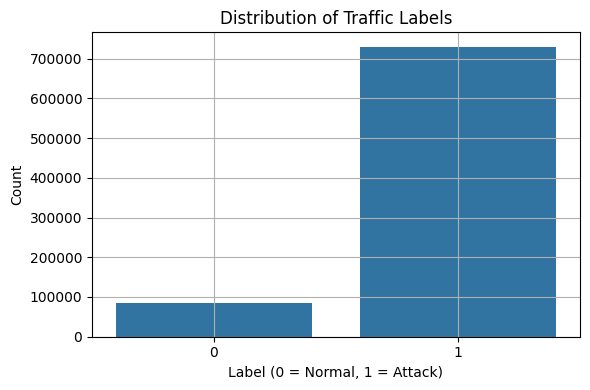

In [25]:
# 1. Label Distribution
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.countplot(x="label", data=df)
plt.title("Distribution of Traffic Labels")
plt.xlabel("Label (0 = Normal, 1 = Attack)")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

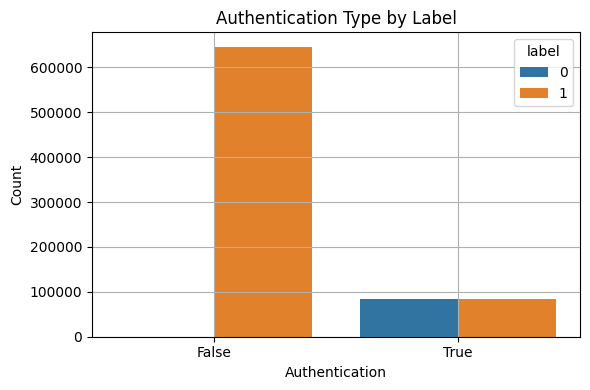

In [26]:
# 2. Authentication vs Label
plt.figure(figsize=(6, 4))
sns.countplot(x="Authentication", hue="label", data=df)
plt.title("Authentication Type by Label")
plt.xlabel("Authentication")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

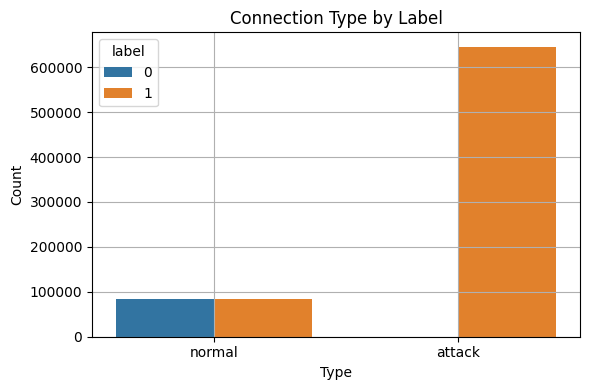

In [27]:
# 3. Type vs Label
plt.figure(figsize=(6, 4))
sns.countplot(x="Type", hue="label", data=df)
plt.title("Connection Type by Label")
plt.xlabel("Type")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

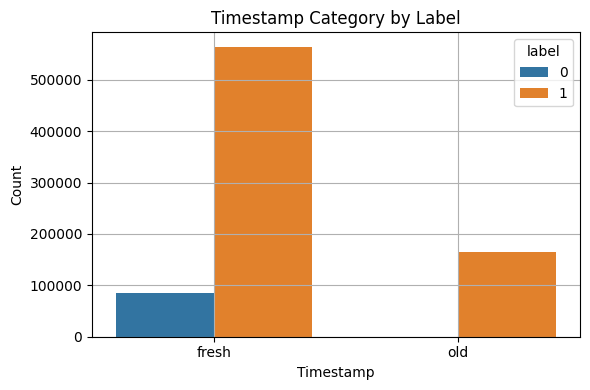

In [28]:
# 4. Timestamp (fresh/stale) vs Label
plt.figure(figsize=(6, 4))
sns.countplot(x="Timestamp", hue="label", data=df)
plt.title("Timestamp Category by Label")
plt.xlabel("Timestamp")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

# Model Development

In [29]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc
)
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# Sample the dataset to 10,000 rows (stratified)
df_sampled = df.groupby('label', group_keys=False).apply(lambda x: x.sample(min(len(x), 5000))).reset_index(drop=True)

# Separate label
y_true = df_sampled['label']
df_sampled.drop(columns=['label'], inplace=True)

# Encode categoricals
for col in df_sampled.select_dtypes(include='object').columns:
    df_sampled[col] = LabelEncoder().fit_transform(df_sampled[col])

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(df_sampled)

# Helper for ROC-AUC
def safe_roc_auc(y_true, y_pred):
    if len(np.unique(y_pred)) < 2:
        return float('nan'), None, None
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    return roc_auc_score(y_true, y_pred), fpr, tpr

# Store results
results = {}
roc_curves = {}

/tmp/ipython-input-29-1326196827.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby('label', group_keys=False).apply(lambda x: x.sample(min(len(x), 5000))).reset_index(drop=True)


**Isolation Forest**

In [30]:
iso = IsolationForest(contamination=0.1, random_state=42)
iso_pred = (iso.fit_predict(X) == -1).astype(int)

auc_score, fpr, tpr = safe_roc_auc(y_true, iso_pred)
results["Isolation Forest"] = {
    "Accuracy": accuracy_score(y_true, iso_pred),
    "Precision": precision_score(y_true, iso_pred),
    "Recall": recall_score(y_true, iso_pred),
    "F1-Score": f1_score(y_true, iso_pred),
    "ROC-AUC": auc_score
}
if fpr is not None:
    roc_curves["Isolation Forest"] = (fpr, tpr)

**KMeans Clustering**

In [31]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_pred = kmeans.fit_predict(X)
if accuracy_score(y_true, kmeans_pred) < 0.5:
    kmeans_pred = 1 - kmeans_pred

auc_score, fpr, tpr = safe_roc_auc(y_true, kmeans_pred)
results["KMeans"] = {
    "Accuracy": accuracy_score(y_true, kmeans_pred),
    "Precision": precision_score(y_true, kmeans_pred),
    "Recall": recall_score(y_true, kmeans_pred),
    "F1-Score": f1_score(y_true, kmeans_pred),
    "ROC-AUC": auc_score
}
if fpr is not None:
    roc_curves["KMeans"] = (fpr, tpr)

**DBSCAN**

In [32]:
dbscan = DBSCAN(eps=3, min_samples=10)
db_pred = dbscan.fit_predict(X)
db_pred = np.where(db_pred == -1, 1, 0)

auc_score, fpr, tpr = safe_roc_auc(y_true, db_pred)
results["DBSCAN"] = {
    "Accuracy": accuracy_score(y_true, db_pred),
    "Precision": precision_score(y_true, db_pred, zero_division=0),
    "Recall": recall_score(y_true, db_pred, zero_division=0),
    "F1-Score": f1_score(y_true, db_pred, zero_division=0),
    "ROC-AUC": auc_score
}
if fpr is not None:
    roc_curves["DBSCAN"] = (fpr, tpr)

**Autoencoder**

In [33]:
input_dim = X.shape[1]
X_train, X_val = train_test_split(X, test_size=0.1, random_state=42)

input_layer = Input(shape=(input_dim,))
encoded = Dense(32, activation='relu')(input_layer)
encoded = Dense(16, activation='relu')(encoded)
decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
autoencoder.fit(X_train, X_train, epochs=20, batch_size=64,
                shuffle=True, validation_data=(X_val, X_val),
                callbacks=[early_stop], verbose=0)

reconstructions = autoencoder.predict(X, verbose=0)
mse = np.mean(np.power(X - reconstructions, 2), axis=1)
threshold = np.percentile(mse, 90)
ae_pred = (mse > threshold).astype(int)

auc_score, fpr, tpr = safe_roc_auc(y_true, ae_pred)
results["Autoencoder"] = {
    "Accuracy": accuracy_score(y_true, ae_pred),
    "Precision": precision_score(y_true, ae_pred),
    "Recall": recall_score(y_true, ae_pred),
    "F1-Score": f1_score(y_true, ae_pred),
    "ROC-AUC": auc_score
}
if fpr is not None:
    roc_curves["Autoencoder"] = (fpr, tpr)

# Evaluation

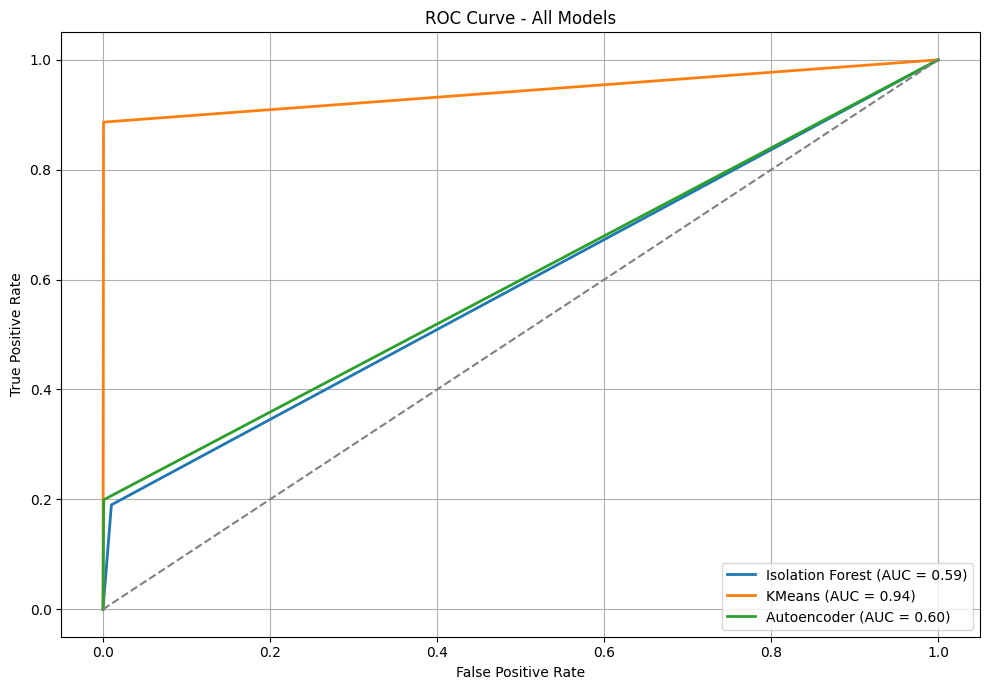

In [34]:
# -------- Plot ROC Curves --------
plt.figure(figsize=(10, 7))
for model, (fpr, tpr) in roc_curves.items():
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{model} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - All Models')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
# -------- Print Metrics --------
print("\nFinal Evaluation Metrics:")
for model, metrics in results.items():
    print(f"\n{model}:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")



Final Evaluation Metrics:

Isolation Forest:
Accuracy: 0.5900
Precision: 0.9500
Recall: 0.1900
F1-Score: 0.3167
ROC-AUC: 0.5900

KMeans:
Accuracy: 0.9430
Precision: 0.9993
Recall: 0.8866
F1-Score: 0.9396
ROC-AUC: 0.9430

DBSCAN:
Accuracy: 0.5000
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC-AUC: nan

Autoencoder:
Accuracy: 0.5992
Precision: 0.9960
Recall: 0.1992
F1-Score: 0.3320
ROC-AUC: 0.5992
